In [1]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('clean_data.csv')
display(df.head(10))

,age,gender,device_type,time_on_site,pages_viewed,previous_purchases,cart_items,discount_seen,ad_clicked,returning_user,avg_session_time,bounce_rate,purchase
0,56.0,Female,Desktop,12.90,8.0,13.0,1.0,1.0,1.0,0.0,6.97,28.18,1.0
1,46.0,Male,Mobile,15.63,9.0,4.0,6.0,1.0,1.0,1.0,19.17,86.73,1.0
2,32.0,Female,Mobile,11.64,12.0,11.0,0.0,0.0,0.0,1.0,8.87,83.09,1.0
3,25.0,Female,Mobile,22.71,5.0,10.0,1.0,0.0,0.0,1.0,14.30,79.03,1.0
4,38.0,Female,Mobile,26.35,9.0,12.0,4.0,1.0,0.0,0.0,18.15,55.35,1.0
5,56.0,Female,Desktop,26.60,1.0,12.0,7.0,1.0,1.0,0.0,28.40,13.90,1.0
6,36.0,Male,Mobile,7.60,11.0,11.0,6.0,1.0,1.0,1.0,4.51,13.12,1.0
7,40.0,Female,Mobile,26.98,7.0,5.0,2.0,1.0,0.0,0.0,33.34,12.61,1.0
8,28.0,Female,Mobile,10.90,14.0,7.0,9.0,0.0,0.0,1.0,13.80,85.46,1.0
9,28.0,Female,Mobile,9.97,3.0,14.0,8.0,0.0,0.0,0.0,14.12,14.16,1.0


<Axes: >

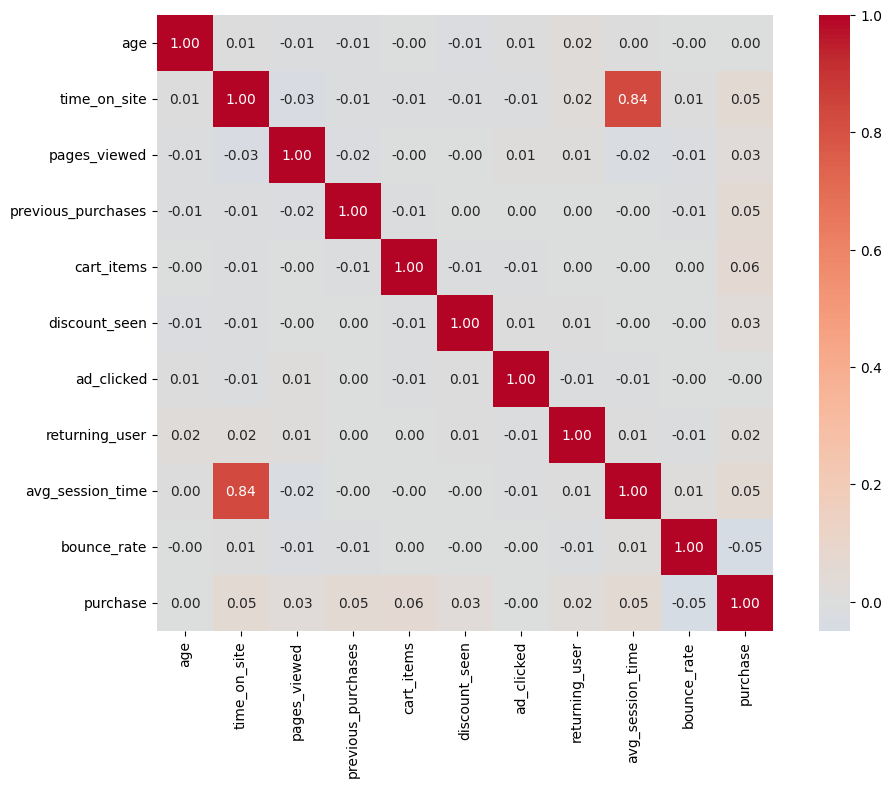

In [3]:
numeric_cols = df.select_dtypes(np.number)
plt.figure(figsize=(12, 8))
sns.heatmap(data=numeric_cols.corr() ,annot=True ,cmap='coolwarm' , center=0 , square=True ,  fmt=".2f")

* time_on_site and avg_session_time have a very high correlation (0.84).

* purchase has extremely weak correlations with all features (highest is only 0.06 with cart_items).

* Slightly Important Features<br>
-> cart_items (0.06)<br>
-> previous_purchases (0.05)<br>
-> bounce_rate (-0.05)<br>

1 . What factors most influence whether a user makes a purchase?

Correlation with purchase (numeric variables):
purchase              1.000000
cart_items            0.057981
time_on_site          0.054369
previous_purchases    0.053124
avg_session_time      0.050513
discount_seen         0.028948
pages_viewed          0.025782
returning_user        0.023294
age                   0.001003
ad_clicked           -0.002116
bounce_rate          -0.049942
Name: purchase, dtype: float64


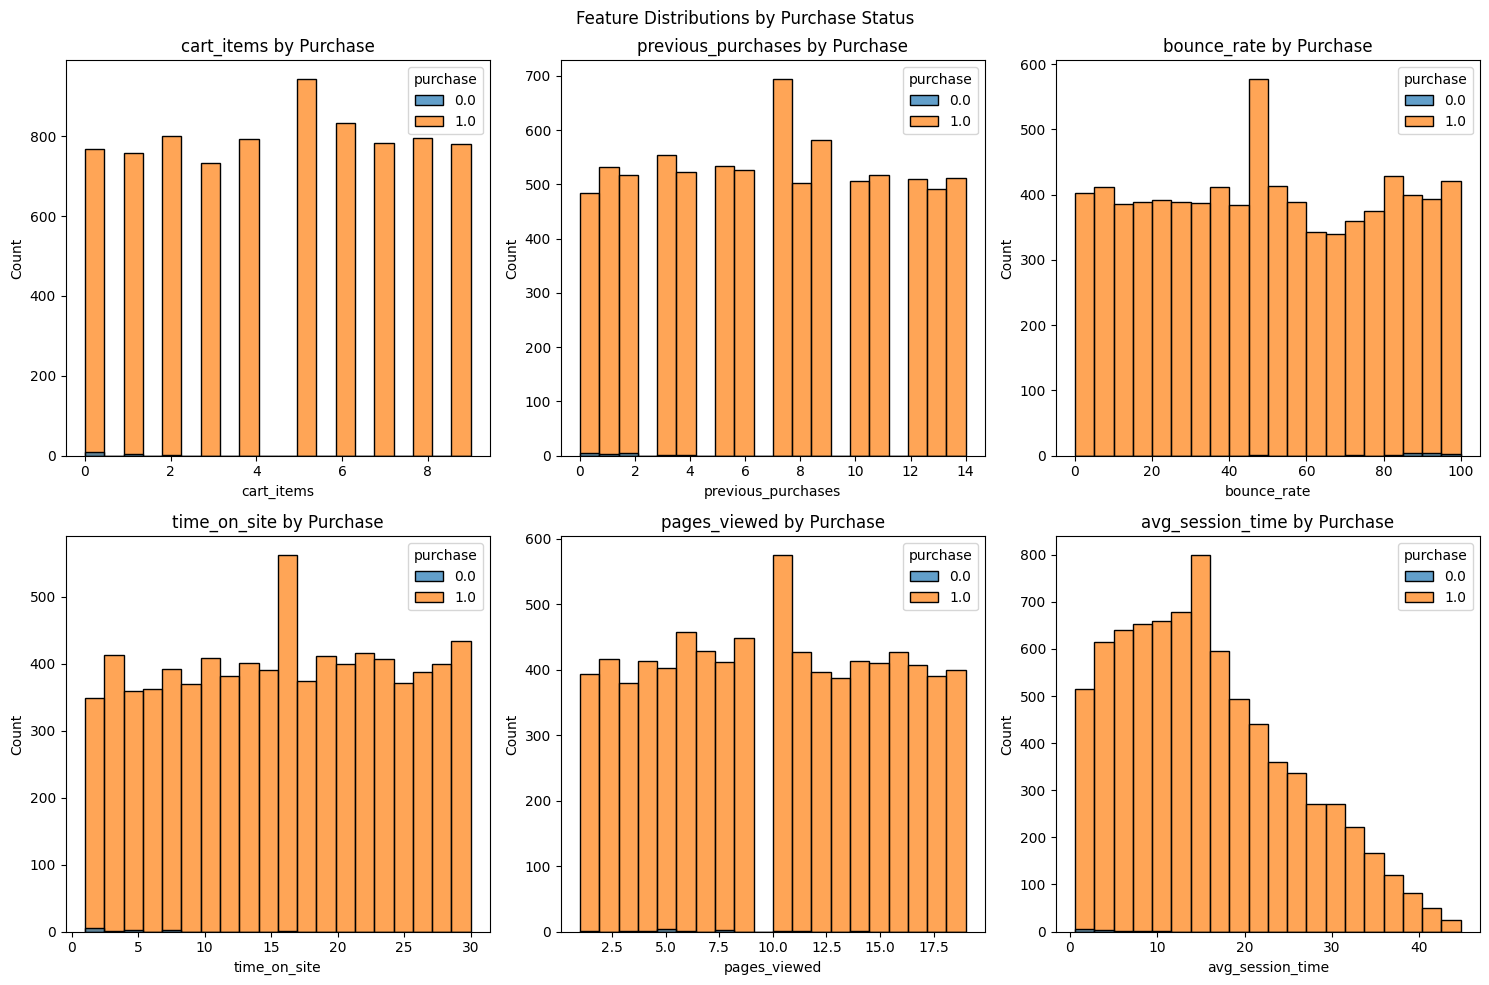

In [ ]:
# Analyze factors influencing purchase
print("Correlation with purchase (numeric variables):")
numeric_cols = df.select_dtypes(include=[np.number])
purchase_corr = numeric_cols.corr()['purchase'].sort_values(ascending=False)
print(purchase_corr)

# Visualize distributions for key features
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Feature Distributions by Purchase Status')

features = ['cart_items', 'previous_purchases', 'bounce_rate', 'time_on_site', 'pages_viewed', 'avg_session_time']

for i, feature in enumerate(features):
    ax = axes[i//3, i%3]
    sns.histplot(data=df, x=feature, hue='purchase', ax=ax, alpha=0.7, bins=20)
    ax.set_title(f'{feature} by Purchase')

plt.tight_layout()
plt.show()